In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
train = pd.read_csv("../data_sample/train.csv")
test = pd.read_csv("../data_sample/test.csv")
data = pd.read_csv("../data_sample/Datos.csv")

In [3]:
from utils.funciones import diagramas_barras, diagrama_dispersion, boxplot_histograma, comparar_cualitativas, histograma_por_categorias, \
    get_features_cat_regression, plot_features_cat_regression, plot_features_num_regression

## Exploración inicial

In [4]:
variables = list(set(train.columns) - set(data.columns))
variables.extend(["zona", "metros"])
variables

['flag_rebaja',
 'pct_rebaja',
 'baños_limpio',
 'ascensor_limpio',
 'flag_loft',
 'localizacion_limpio',
 'planta_limpio',
 'barrio',
 'flag_nuda_propiedad',
 'flag_alquilada',
 'tipo_inmueble',
 'flag_okupada',
 'habitaciones_limpio',
 'flag_proindiviso',
 'flag_subasta',
 'zona',
 'metros']

In [5]:
target = "PrecioActual"

### Target: PrecioActual

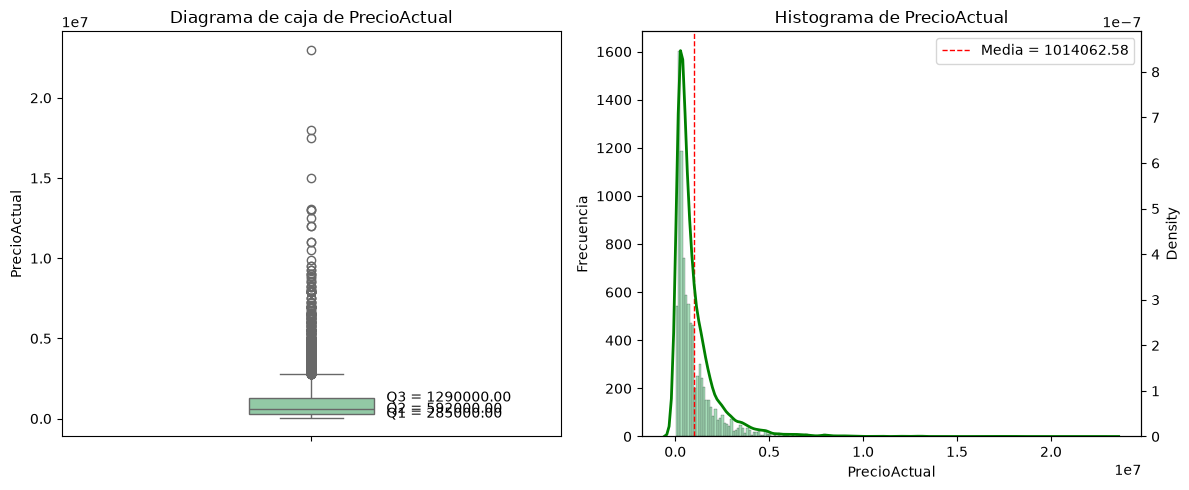

In [6]:
boxplot_histograma(train, target)

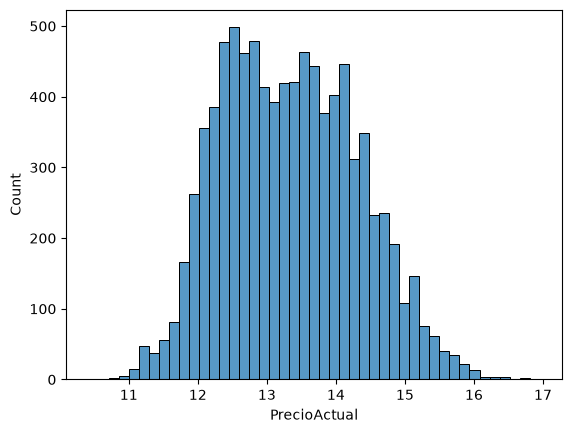

In [7]:
sns.histplot(train[target].transform("log"));

In [8]:
train[target + "_log"] = train[target].transform("log")

In [9]:
new_target = target + "_log"

### Veamos el nº de datos únicos de cada variable

In [10]:
serie_unicos = pd.Series({var:train[var].nunique() for var in variables}, name="nUnique")
serie_unicos.sort_values(ascending=True, inplace=True)
serie_unicos

flag_rebaja              2
flag_loft                2
flag_alquilada           2
flag_subasta             2
flag_proindiviso         2
flag_okupada             2
flag_nuda_propiedad      2
localizacion_limpio      4
ascensor_limpio          4
baños_limpio             7
tipo_inmueble            9
habitaciones_limpio     18
zona                    21
planta_limpio           27
barrio                 139
pct_rebaja             418
metros                 583
Name: nUnique, dtype: int64

Las únicas que podemos considerar numéricas son `habitaciones_limpio`, `planta_limpio`, `metros` y `pct_rebaja`, pero `planta_limpio` tiene valores cualitativos y `habitaciones_limpio` tiene nans.

#### Habitaciones

In [11]:
scipy.stats.pearsonr(x=train.loc[train.habitaciones_limpio.notna(), "habitaciones_limpio"], y=train.loc[train.habitaciones_limpio.notna(), target])

PearsonRResult(statistic=np.float64(0.5064984785943474), pvalue=np.float64(0.0))

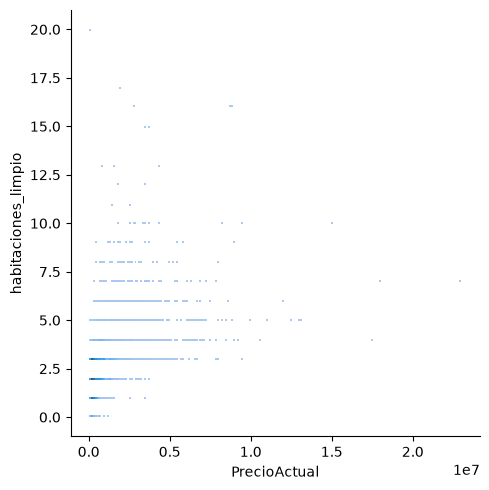

In [15]:
sns.displot(train, x=target, y="habitaciones_limpio");

Habitaciones da un coeficiente de pearson con p-valor 0, que es muy extraño. Además hemos tenido que quitar los nans, no tiene buena pinta.

#### Rebaja

In [16]:
train.pct_rebaja.value_counts(True)

pct_rebaja
0.00     0.904661
2.86     0.001453
5.00     0.001453
4.35     0.001341
3.12     0.000894
           ...   
13.33    0.000112
13.09    0.000112
9.96     0.000112
2.46     0.000112
1.17     0.000112
Name: proportion, Length: 418, dtype: float64

Rebaja tiene un 90% de ceros, por lo que tiene mas sentido tratarla como una variable categórica binaria sobre si hay rebaja o no.

In [17]:
train["rebaja"] = (train.pct_rebaja != 0).astype(int)

In [18]:
variables.remove("pct_rebaja")
variables.append("rebaja")

#### Metros

In [19]:
scipy.stats.pearsonr(x=train.loc[train.metros.notna(), "metros"], y=train.loc[train.metros.notna(), target])

PearsonRResult(statistic=np.float64(0.7175300164760341), pvalue=np.float64(0.0))

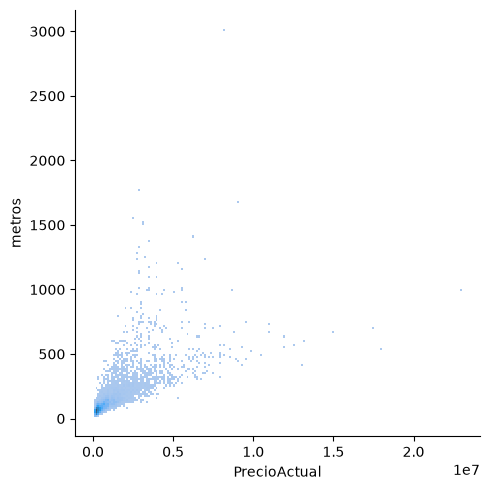

In [20]:
sns.displot(train, x=target, y="metros");

### Análisis de categóricas
Tenemos que quitar las variabels con nulos para poder hacer los estadísticos.

In [22]:
train[variables].info()

<class 'pandas.DataFrame'>
RangeIndex: 8947 entries, 0 to 8946
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   flag_rebaja          8947 non-null   int64  
 1   baños_limpio         1948 non-null   float64
 2   ascensor_limpio      8947 non-null   str    
 3   flag_loft            8947 non-null   int64  
 4   localizacion_limpio  8947 non-null   str    
 5   planta_limpio        8947 non-null   str    
 6   barrio               8947 non-null   str    
 7   flag_nuda_propiedad  8947 non-null   int64  
 8   flag_alquilada       8947 non-null   int64  
 9   tipo_inmueble        8947 non-null   str    
 10  flag_okupada         8947 non-null   int64  
 11  habitaciones_limpio  8926 non-null   float64
 12  flag_proindiviso     8947 non-null   int64  
 13  flag_subasta         8947 non-null   int64  
 14  zona                 8947 non-null   str    
 15  metros               8947 non-null   int64  
 16 

In [23]:
vars_sin_nan = variables.copy()
vars_sin_nan.remove("baños_limpio")
vars_sin_nan.remove("habitaciones_limpio")
vars_sin_nan.extend([target, new_target])

In [24]:
vars_significativas = get_features_cat_regression(train[vars_sin_nan], target)    # vars significativas a 0.05
vars_significativas

['flag_rebaja',
 'ascensor_limpio',
 'flag_loft',
 'localizacion_limpio',
 'flag_nuda_propiedad',
 'flag_alquilada',
 'tipo_inmueble',
 'flag_okupada',
 'flag_proindiviso',
 'flag_subasta',
 'rebaja']

In [25]:
# No hay diferencia en las variables significativas con el target transformado
set(vars_significativas)& set(get_features_cat_regression(train[vars_sin_nan], new_target)) == set(vars_significativas)

True

Vamos a añadir metros y habitaciones, que son variables numéricas también significativas.

In [27]:
vars_significativas.extend(["habitaciones_limpio", "metros"])

Revisemos ahora las variables con NaNs.
- `baños_limpio`:

In [28]:
grupos = [train.loc[train["baños_limpio"] == clase, target] for clase in train["baños_limpio"].dropna(inplace=False).unique()]
if 1 in [len(grupo) for grupo in grupos]:
    pval_stat = scipy.stats.kruskal(*grupos)[1] # para poblaciones con tamaño muestral pequeño
else:
    pval_stat = scipy.stats.f_oneway(*grupos)[1]

pval_stat

np.float64(1.0663130348902189e-138)

In [29]:
vars_significativas.append("baños_limpio")

In [30]:
# Veamos si hay alguna diferencia con el target transformado
grupos = [train.loc[train["baños_limpio"] == clase, new_target] for clase in train["baños_limpio"].dropna(inplace=False).unique()]
if 1 in [len(grupo) for grupo in grupos]:
    pval_stat = scipy.stats.kruskal(*grupos)[1] # para poblaciones con tamaño muestral pequeño
else:
    pval_stat = scipy.stats.f_oneway(*grupos)[1]

pval_stat   # es aun más significativa

np.float64(1.0808029532200806e-163)

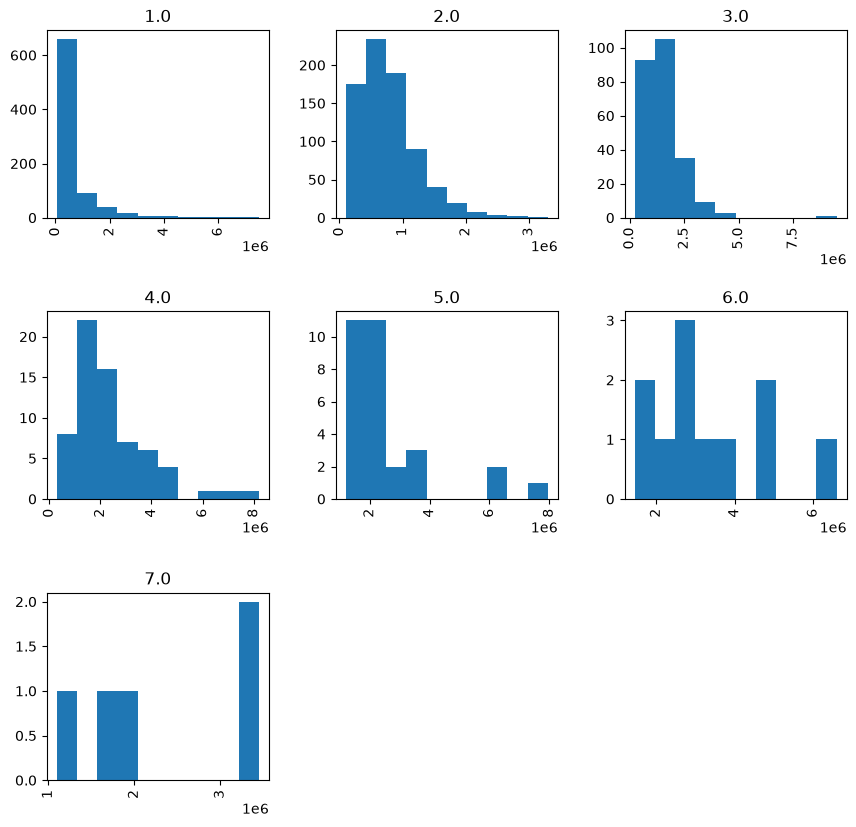

In [33]:
train.hist(column=target, by="baños_limpio", figsize=(10, 10));

- `habitaciones_limpio`, esta vez incluyendo los nulos:

In [31]:
grupos = [train.loc[train["habitaciones_limpio"] == clase, target] for clase in train["habitaciones_limpio"].dropna(inplace=False).unique()]
if 1 in [len(grupo) for grupo in grupos]:
    pval_stat = scipy.stats.kruskal(*grupos)[1] # para poblaciones con tamaño muestral pequeño
else:
    pval_stat = scipy.stats.f_oneway(*grupos)[1]

pval_stat

np.float64(0.0)

In [32]:
grupos = [train.loc[train["habitaciones_limpio"] == clase, new_target] for clase in train["habitaciones_limpio"].dropna(inplace=False).unique()]
if 1 in [len(grupo) for grupo in grupos]:
    pval_stat = scipy.stats.kruskal(*grupos)[1] # para poblaciones con tamaño muestral pequeño
else:
    pval_stat = scipy.stats.f_oneway(*grupos)[1]

pval_stat

np.float64(0.0)

## Features seleccionadas

In [34]:
vars_significativas

['flag_rebaja',
 'ascensor_limpio',
 'flag_loft',
 'localizacion_limpio',
 'flag_nuda_propiedad',
 'flag_alquilada',
 'tipo_inmueble',
 'flag_okupada',
 'flag_proindiviso',
 'flag_subasta',
 'rebaja',
 'habitaciones_limpio',
 'metros',
 'baños_limpio']

In [35]:
len(vars_significativas)

14

In [36]:
set(variables)-set(vars_significativas)

{'barrio', 'planta_limpio', 'zona'}

Estas variables se pueden incluir en un Catboost a ver si puede mejorar el modelo.

En el caso de `planta`, tiene sentido que no sea significativo porque, mientras que para un piso 27 el precio será claramente alto al tratarse de un edificio muy alto, para plantas bajas no tiene forma de saber el tamaño del edificio y, por tanto, su valor dentro de un margen. Sería mejor tener una variable `pisos_edificio` con el número de pisos que tiene el edificio en el que se encuentra el piso.

De igual manera, `barrio` y `zona` pueden servir para explicar los barrios más caros o más baratos, mientras que como tal la variable no resulta significativa por una gran canditdad de poblaciones similares. 

## Interacciones entre variables

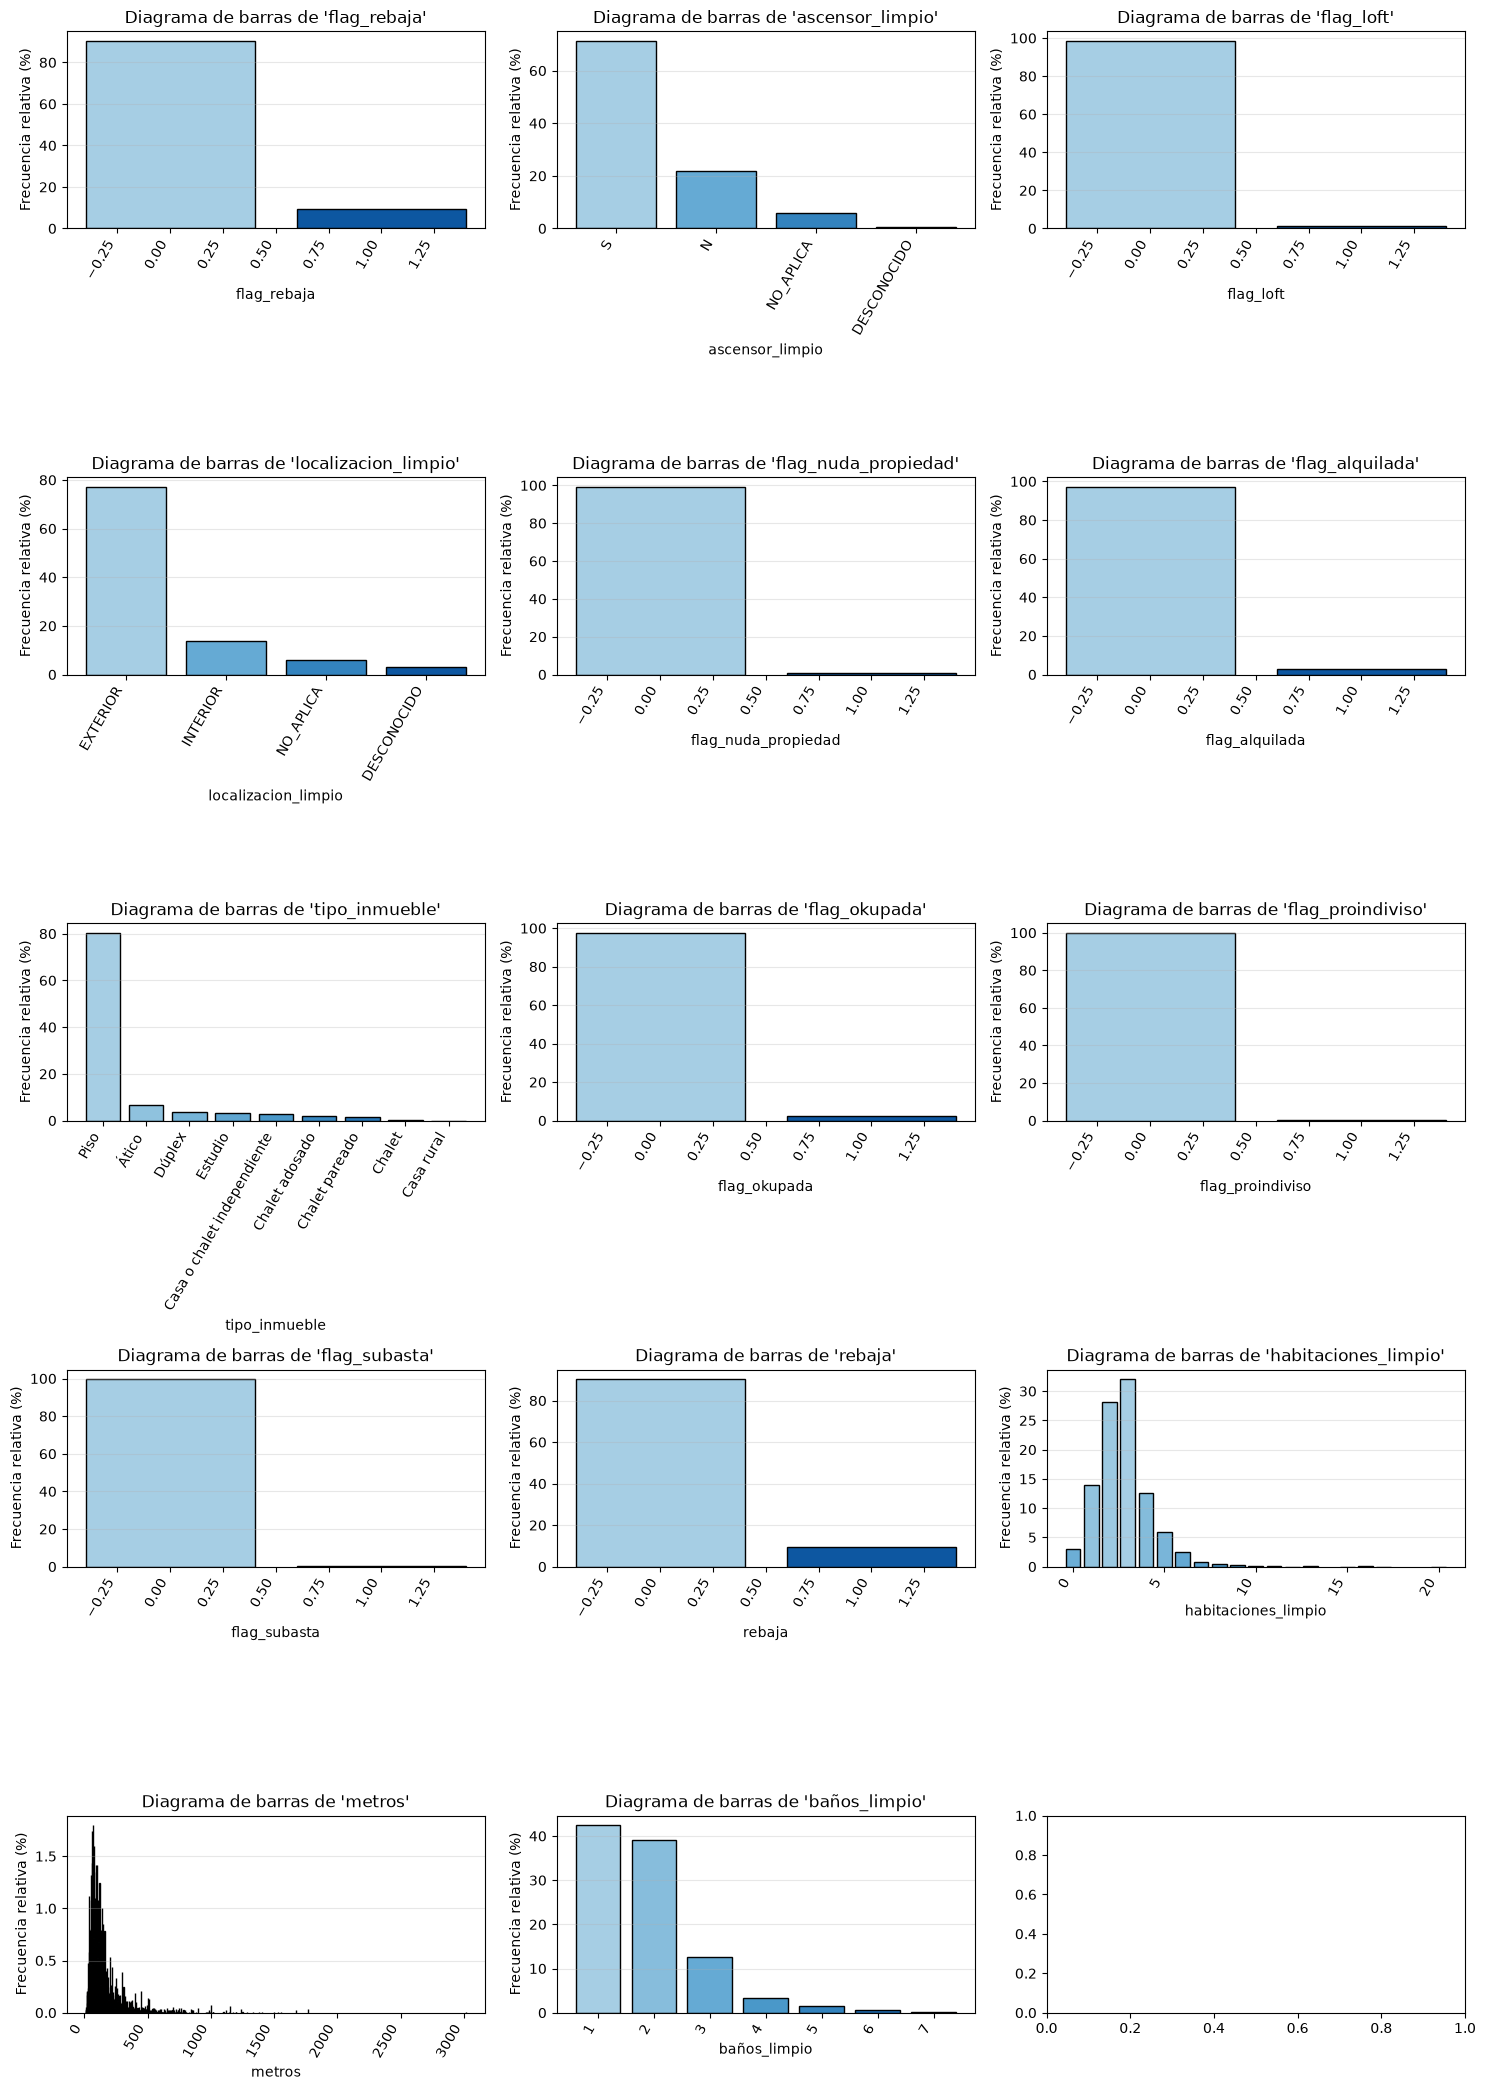

In [37]:
diagramas_barras(train, vars_significativas, relativo=True)

#### Relación con `habitaciones_limpio`

In [43]:
relaciones = pd.DataFrame(np.zeros((len(vars_significativas), len(vars_significativas))), columns=vars_significativas, index=vars_significativas)

In [44]:
for var in vars_significativas:
    if var != "habitaciones_limpio":
        clases = [clase for clase in train.loc[train[var].notna(), var].unique()]
        grupos = [train.loc[(train[var] == clase)&(train.habitaciones_limpio.notna()), "habitaciones_limpio"] for clase in clases]
        print(f"ANOVA para las poblaciones de habitaciones_limpio según {var}:")
        stat, pval = scipy.stats.f_oneway(*grupos)
        print(stat, pval)
        if pval <= 0.05:
            relaciones.loc[var,"habitaciones_limpio"] = 1
            relaciones.loc["habitaciones_limpio", var] = 1
        print()

ANOVA para las poblaciones de habitaciones_limpio según flag_rebaja:
3.2851514681706995 0.06994276743694848

ANOVA para las poblaciones de habitaciones_limpio según ascensor_limpio:
778.6312958248643 0.0

ANOVA para las poblaciones de habitaciones_limpio según flag_loft:
107.13184213958762 5.764257369395032e-25

ANOVA para las poblaciones de habitaciones_limpio según localizacion_limpio:
871.756774921195 0.0

ANOVA para las poblaciones de habitaciones_limpio según flag_nuda_propiedad:
0.035571091951836324 0.8504082692725041

ANOVA para las poblaciones de habitaciones_limpio según flag_alquilada:
33.8313350108037 6.217243235267317e-09

ANOVA para las poblaciones de habitaciones_limpio según tipo_inmueble:
470.62283115543397 0.0

ANOVA para las poblaciones de habitaciones_limpio según flag_okupada:
12.85402451752594 0.0003385528849977091

ANOVA para las poblaciones de habitaciones_limpio según flag_proindiviso:
0.060577116168694996 0.805591759701687

ANOVA para las poblaciones de habitac

C:\Users\manza\AppData\Local\Temp\ipykernel_21500\1946830044.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pval = scipy.stats.f_oneway(*grupos)


#### Relación con `metros`

In [45]:
for var in vars_significativas:
    if var not in ["habitaciones_limpio", "metros"]:
        clases = [clase for clase in train.loc[train[var].notna(), var].unique()]
        grupos = [train.loc[(train[var] == clase)&(train.metros.notna()), "metros"] for clase in clases]
        print(f"ANOVA para las poblaciones de metros según {var}:")
        stat, pval = scipy.stats.f_oneway(*grupos)
        print(stat, pval)
        if pval <= 0.05:
            relaciones.loc[var,"metros"] = 1
            relaciones.loc["metros", var] = 1
        print()

ANOVA para las poblaciones de metros según flag_rebaja:
17.00012913919185 3.7715098983486725e-05

ANOVA para las poblaciones de metros según ascensor_limpio:
1599.751935555087 0.0

ANOVA para las poblaciones de metros según flag_loft:
14.549325619247682 0.0001374560287005979

ANOVA para las poblaciones de metros según localizacion_limpio:
1516.6660563440273 0.0

ANOVA para las poblaciones de metros según flag_nuda_propiedad:
4.652370033153651 0.031037259382731115

ANOVA para las poblaciones de metros según flag_alquilada:
52.20636854137004 5.405833660748667e-13

ANOVA para las poblaciones de metros según tipo_inmueble:
781.8688675525623 0.0

ANOVA para las poblaciones de metros según flag_okupada:
53.58860534023417 2.6855537270114555e-13

ANOVA para las poblaciones de metros según flag_proindiviso:
3.5473233164752237e-07 0.9995247979728142

ANOVA para las poblaciones de metros según flag_subasta:
2.668014815439611 0.10241885212378009

ANOVA para las poblaciones de metros según rebaja:


### Variables cualitativas

In [46]:
from scipy.stats import chi2_contingency
for i in range(len(vars_significativas)):
    for j in range(i+1, len(vars_significativas)):
        if (vars_significativas[i] not in ["habitaciones_limpio", "metros"]) & (vars_significativas[j] not in ["habitaciones_limpio", "metros"]):
            var1 = vars_significativas[i]
            var2 = vars_significativas[j]
            tabla_contingencia = pd.crosstab(train[var1], train[var2])

            chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
            print(f"TEST CHI CUADRADO: {var1} - {var2}")
            print("Valor Chi-Cuadrado:", chi2)
            print("P-Value:", p)
            print()

            if p <= 0.05:
                relaciones.loc[var1,var2] = 1
                relaciones.loc[var2, var1] = 1

TEST CHI CUADRADO: flag_rebaja - ascensor_limpio
Valor Chi-Cuadrado: 34.20500904259521
P-Value: 1.7932601976286264e-07

TEST CHI CUADRADO: flag_rebaja - flag_loft
Valor Chi-Cuadrado: 0.01638902309453638
P-Value: 0.8981334463157382

TEST CHI CUADRADO: flag_rebaja - localizacion_limpio
Valor Chi-Cuadrado: 20.570722340356603
P-Value: 0.00012925316594444605

TEST CHI CUADRADO: flag_rebaja - flag_nuda_propiedad
Valor Chi-Cuadrado: 0.7779149316614775
P-Value: 0.3777795872863553

TEST CHI CUADRADO: flag_rebaja - flag_alquilada
Valor Chi-Cuadrado: 0.47533423813649506
P-Value: 0.4905433508168249

TEST CHI CUADRADO: flag_rebaja - tipo_inmueble
Valor Chi-Cuadrado: 14.357228579705335
P-Value: 0.07291656401205965

TEST CHI CUADRADO: flag_rebaja - flag_okupada
Valor Chi-Cuadrado: 49.19717416099923
P-Value: 2.3148393573624175e-12

TEST CHI CUADRADO: flag_rebaja - flag_proindiviso
Valor Chi-Cuadrado: 0.0
P-Value: 1.0

TEST CHI CUADRADO: flag_rebaja - flag_subasta
Valor Chi-Cuadrado: 0.0099658505082325

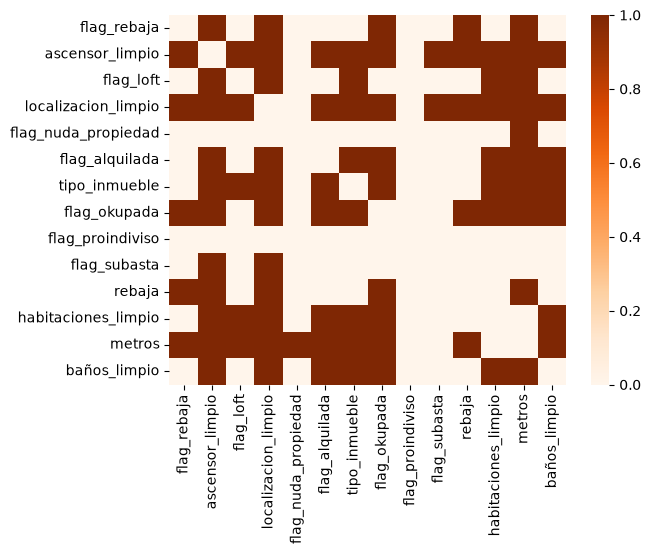

In [47]:
sns.heatmap(relaciones, cmap="Oranges");

`ascensor` tiene muchas relaciones significativas de dependencia con otras variables. A lo mejor hay que quitarla, dependiendo de cómo funcione dentro del modelo. `metros` parece que también, pero la información que proporciona metros es muy clara y de utilidad directa. 